# Pose experiment suite — real / synthetic / mixed

Repete a avaliação de `classifiers_robot_emotions.ipynb` para três configurações de fonte de pose:

| Experimento | Pose | IMU sintético |
|---|---|---|
| `real_pose` | MotionBERT (vídeo real) | pipeline real |
| `synthetic_pose` | Kimodo (geração a partir de janelas reais) | pipeline Kimodo |
| `mixed_pose` | real + sintético juntos | idem ao modo correspondente |

Cada experimento de pose roda exatamente o mesmo `run_experiment_suite` do notebook original.

In [4]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / 'pose_module').exists() and (root / 'evaluation').exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.classifiers import (
    ALL_CAPTURE_BLACKLIST,
    WindowedDatasetConfig,
    build_classifier_capture_table,
    build_windowed_multimodal_dataset,
)

try:
    from evaluation.classifiers import (
        EXPERIMENT_SPECS,
        ModelConfig,
        SplitConfig,
        TrainingConfig,
        run_experiment_suite,
    )
    TORCH_READY = True
    TORCH_IMPORT_ERROR = None
except ImportError as exc:
    TORCH_READY = False
    TORCH_IMPORT_ERROR = exc

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 260)
PROJECT_ROOT

PosixPath('/home/henriquesouza/IMUGPT')

## Configuração dos experimentos

- `REAL_OUTPUT_ROOT` — diretório do pipeline real (contém `virtual_imu_manifest.jsonl` + `imu.npz` por clipe)
- `SYNTHETIC_MANIFEST` — manifesto gerado por `export-kimodo-virtual-imu`
- `MIXED_MANIFEST` — manifesto gerado por `export-mixed-virtual-imu`

In [5]:
REAL_OUTPUT_ROOT     = PROJECT_ROOT / 'output' / 'exp_real_pose'
SYNTHETIC_MANIFEST   = PROJECT_ROOT / 'output' / 'exp_synthetic_pose' / 'virtual_imu_manifest.jsonl'
MIXED_MANIFEST       = PROJECT_ROOT / 'output' / 'exp_mixed_pose'      / 'mixed_virtual_imu_manifest.jsonl'
ANCHOR_CATALOG       = PROJECT_ROOT / 'output' / 'robot_emotions_kimodo_anchors_effectors_5' / 'kimodo_anchor_catalog.jsonl'

IMU_FEATURE_MODE = 'acc_euler'

# Emoções excluídas manualmente da classificação (amostras insuficientes por sujeito)
EXCLUDED_EMOTIONS = {'Fear', 'Anger'}

DATASET_CONFIG = WindowedDatasetConfig(
    window_size=81,
    overlap=0.5,
    synthetic_variant='raw',
    imu_feature_mode=IMU_FEATURE_MODE,
    selected_sensors=None,
    max_windows_per_capture=None,
    random_state=42,
)

SPLIT_CONFIG = SplitConfig(n_splits=5, random_state=42) if TORCH_READY else None
MODEL_CONFIG = ModelConfig(hidden_dim=128, dropout=0.1, trunk_blocks=2, modality_dropout_p=0.1) if TORCH_READY else None
TRAINING_CONFIG = TrainingConfig(
    batch_size=64, max_epochs=10, learning_rate=2e-3, weight_decay=1e-4,
    device='cuda',
    domain_loss_weight=0.1, flat_tag_loss_weight=0.3, emotion_loss_weight=1.0,
    modality_loss_weight=0.3, stimulus_loss_weight=0.3, use_cb_focal=False,
) if TORCH_READY else None

REQUESTED_ORDER = [
    'vision_only', 'imu_only_r2r', 'imu_only_s2r', 'imu_only_mixed2r',
    'vision_imu_r2r', 'vision_imu_s2r', 'vision_imu_mixed2r',
]

print('REAL_OUTPUT_ROOT:', REAL_OUTPUT_ROOT)
print('SYNTHETIC_MANIFEST:', SYNTHETIC_MANIFEST)
print('MIXED_MANIFEST:', MIXED_MANIFEST)
print('ANCHOR_CATALOG:', ANCHOR_CATALOG)
print('TORCH_READY:', TORCH_READY)
print('EXCLUDED_EMOTIONS:', EXCLUDED_EMOTIONS)

REAL_OUTPUT_ROOT: /home/henriquesouza/IMUGPT/output/exp_real_pose
SYNTHETIC_MANIFEST: /home/henriquesouza/IMUGPT/output/exp_synthetic_pose/virtual_imu_manifest.jsonl
MIXED_MANIFEST: /home/henriquesouza/IMUGPT/output/exp_mixed_pose/mixed_virtual_imu_manifest.jsonl
ANCHOR_CATALOG: /home/henriquesouza/IMUGPT/output/robot_emotions_kimodo_anchors_effectors_5/kimodo_anchor_catalog.jsonl
TORCH_READY: True
EXCLUDED_EMOTIONS: {'Anger', 'Fear'}


## Helpers para carregar manifestos sintéticos

O manifesto sintético não tem `domain`/`user_id`/`tag_number` — esses campos vêm do manifesto real
via `reference_clip_id`. A função abaixo constrói uma capture table compatível com
`build_windowed_multimodal_dataset`.

In [6]:
from pose_module.robot_emotions.metadata import get_protocol_info


def _load_real_manifest_index(real_output_root: Path) -> pd.DataFrame:
    """Carrega o manifesto real e indexa por clip_id para lookup de metadados."""
    path = real_output_root / 'virtual_imu_manifest.jsonl'
    rows = []
    for line in path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        clip_dir = str(Path(e['artifacts']['virtual_imu_npz_path']).parent.parent.parent.resolve())
        rows.append({
            'clip_id':      str(e['clip_id']),
            'domain':       str(e['domain']),
            'user_id':      int(e['user_id']),
            'tag_number':   int(e['tag_number']),
            'take_id':      e.get('take_id'),
            'clip_dir':     clip_dir,
        })
    return pd.DataFrame(rows).set_index('clip_id')


def _load_anchor_catalog_index(anchor_catalog_path: Path) -> dict[str, tuple[float, float]]:
    """Indexa o anchor catalog por window_id → (start_sec, end_sec)."""
    index = {}
    for line in anchor_catalog_path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        wid = e.get('window_id') or e.get('prompt_id')
        if wid and 'window' in e and e['window']:
            index[wid] = (float(e['window']['start_sec']), float(e['window']['end_sec']))
    return index


def _build_synthetic_capture_table(
    manifest_path: Path,
    real_index: pd.DataFrame,
    anchor_index: dict[str, tuple[float, float]],
    *,
    pose_kind_filter: str | None = None,
) -> pd.DataFrame:
    """
    Constrói capture table a partir de um manifesto sintético ou misto.

    emotion/modality/stimulus vêm de get_protocol_info(domain, tag_number) —
    as mesmas classes canônicas usadas pelo experimento real — e não dos
    labels livres do manifesto de geração.
    """
    rows = []
    for line in manifest_path.read_text(encoding='utf-8').splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        if e.get('status') not in ('ok', 'warning'):
            continue
        pose_kind = e.get('pose_kind', 'synthetic')
        if pose_kind_filter is not None and pose_kind != pose_kind_filter:
            continue

        if pose_kind == 'real':
            artifacts = e.get('artifacts', {})
            pose3d_npz = artifacts.get('pose3d_npz_path')
            virtual_imu_npz = artifacts.get('virtual_imu_npz_path')
            ref_clip_id = str(e['clip_id'])
        else:
            va = e.get('virtual_imu_artifacts', {})
            pose3d_npz = va.get('pose3d_npz_path')
            virtual_imu_npz = va.get('virtual_imu_npz_path')
            ref_clip_id = str(e.get('reference_clip_id') or e.get('clip_id'))

        if pose3d_npz is None or virtual_imu_npz is None:
            continue
        if not Path(pose3d_npz).exists() or not Path(virtual_imu_npz).exists():
            continue
        if ref_clip_id not in real_index.index:
            continue

        real_row = real_index.loc[ref_clip_id]
        protocol = get_protocol_info(real_row['domain'], real_row['tag_number']) or {}
        emotion  = str(protocol.get('emotion', ''))
        modality = str(protocol.get('modality', ''))
        stimulus = str(protocol.get('stimulus', 'None'))

        window_id = e.get('window_id')
        real_imu_time_range_sec = anchor_index.get(window_id) if window_id else None

        sample_id = str(e.get('sample_id') or e.get('prompt_id') or e['clip_id'])
        rows.append({
            'clip_id':                            sample_id,
            'reference_clip_id':                  ref_clip_id,
            'domain':                             real_row['domain'],
            'user_id':                            real_row['user_id'],
            'tag_number':                         real_row['tag_number'],
            'take_id':                            real_row['take_id'],
            'emotion':                            emotion,
            'modality':                           modality,
            'stimulus':                           stimulus,
            'status':                             str(e.get('status', 'ok')),
            'pose3d_npz_path':                    pose3d_npz,
            'virtual_imu_npz_path':               virtual_imu_npz,
            'virtual_imu_frame_aligned_npz_path': None,
            'clip_dir':                           real_row['clip_dir'],
            'pose_kind':                          pose_kind,
            'quality_report':                     {},
            'real_imu_time_range_sec':            real_imu_time_range_sec,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    df['subject_group'] = df.apply(
        lambda r: f"{r['domain']}_user_{int(r['user_id']):02d}", axis=1
    )
    df['flat_tag'] = df.apply(
        lambda r: f"{r['emotion']}|{r['modality']}|{r['stimulus']}", axis=1
    )
    df['frame_aligned_available'] = False
    n_with_range = df['real_imu_time_range_sec'].notna().sum()
    print(f'  real_imu_time_range_sec preenchido: {n_with_range}/{len(df)} amostras')
    return df.reset_index(drop=True)


def _apply_emotion_exclusions(df: pd.DataFrame, excluded: set[str]) -> pd.DataFrame:
    """Remove capturas cujas emoções estão em `excluded`."""
    if df.empty or not excluded:
        return df
    mask = df['emotion'].isin(excluded)
    n_dropped = int(mask.sum())
    if n_dropped:
        print(f'  Excluindo {n_dropped} capturas com emoção em {excluded}')
    return df.loc[~mask].reset_index(drop=True)


def _sort_suite_summary(summary_df: pd.DataFrame) -> pd.DataFrame:
    order_map = {name: idx for idx, name in enumerate(REQUESTED_ORDER)}
    df = summary_df.copy()
    df['_sort_key'] = df['experiment_name'].astype(str).map(order_map).fillna(len(REQUESTED_ORDER))
    return df.sort_values('_sort_key', kind='stable').drop(columns=['_sort_key']).reset_index(drop=True)


def _run_pose_experiment(
    label: str,
    captures_df: pd.DataFrame,
) -> dict:
    """Constrói dataset e roda o suite de classificadores para uma capture table."""
    captures_df = _apply_emotion_exclusions(captures_df, EXCLUDED_EMOTIONS)

    display(Markdown(f'### {label} — dataset'))
    display(captures_df[['clip_id', 'domain', 'user_id', 'tag_number', 'emotion', 'modality', 'stimulus', 'status']].head())
    print({'num_captures': len(captures_df), 'domains': sorted(captures_df['domain'].unique().tolist())})

    dataset_bundle = build_windowed_multimodal_dataset(
        REAL_OUTPUT_ROOT,
        config=DATASET_CONFIG,
        captures_df=captures_df,
    )
    display(dataset_bundle['metadata'].head())
    display(dataset_bundle['alignment_summary'].head())
    print({
        'num_samples':          len(dataset_bundle['metadata']),
        'pose_shape':           dataset_bundle['pose_windows'].shape,
        'imu_real_shape':       dataset_bundle['imu_real_windows'].shape,
        'imu_synthetic_shape':  dataset_bundle['imu_synthetic_windows'].shape,
    })

    if not TORCH_READY:
        display(Markdown(f'**PyTorch não disponível**: `{TORCH_IMPORT_ERROR}`'))
        return {'label': label, 'dataset_bundle': dataset_bundle, 'suite_result': None}

    display(Markdown(f'### {label} — suite de classificadores'))
    suite_result = run_experiment_suite(
        dataset_bundle,
        experiment_names=list(EXPERIMENT_SPECS.keys()),
        split_config=SPLIT_CONFIG,
        model_config=MODEL_CONFIG,
        training_config=TRAINING_CONFIG,
    )
    display(_sort_suite_summary(suite_result['summary']))
    display(suite_result['domain_gap_summary'])
    return {'label': label, 'dataset_bundle': dataset_bundle, 'suite_result': suite_result}


REAL_INDEX = _load_real_manifest_index(REAL_OUTPUT_ROOT)
ANCHOR_INDEX = _load_anchor_catalog_index(ANCHOR_CATALOG)
print(f'Real manifest index: {len(REAL_INDEX)} clips')
print(f'Anchor catalog index: {len(ANCHOR_INDEX)} janelas')

Real manifest index: 89 clips
Anchor catalog index: 3726 janelas


---
## Experimento 1 — Apenas pose real

Idêntico ao notebook original. Usa `build_classifier_capture_table` com o manifesto real.

In [7]:
CAPTURES_REAL = build_classifier_capture_table(REAL_OUTPUT_ROOT)
RESULT_REAL   = _run_pose_experiment('real_pose', CAPTURES_REAL)

  Excluindo 4 capturas com emoção em {'Anger', 'Fear'}


### real_pose — dataset

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus,status
0,robot_emotions_10ms_u02_tag01,10ms,2,1,Neutrality,Standing,None,warning
1,robot_emotions_10ms_u02_tag05,10ms,2,5,Sadness,Sitting,Visual methods,warning
2,robot_emotions_10ms_u02_tag06,10ms,2,6,Sadness,Sitting,Autobiographical recall,warning
3,robot_emotions_10ms_u02_tag07,10ms,2,7,Sadness,Standing,Autobiographical recall,warning
4,robot_emotions_10ms_u02_tag09,10ms,2,9,Happiness,Sitting,Visual methods,warning


{'num_captures': 76, 'domains': ['10ms', '30ms']}


,sample_id,capture_id,clip_id,domain,user_id,tag_number,take_id,emotion,modality,stimulus,flat_tag,subject_group,window_index,window_start_index,window_size,window_overlap,quality_status,synthetic_variant,imu_feature_mode,selected_sensors,pose_imu_lag_samples,pose_imu_lag_seconds,pose_imu_correlation_before_dtw,pose_imu_correlation_after_dtw,pose_imu_dtw_normalized_distance,visible_joint_ratio,mean_confidence,temporal_jitter_score,root_drift_score,emotion_id,modality_id,stimulus_id,flat_tag_id
0,robot_emotions_10ms_u02_tag01::window_0000,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,3,1,1,7
1,robot_emotions_10ms_u02_tag01::window_0001,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,40,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,3,1,1,7
2,robot_emotions_10ms_u02_tag01::window_0002,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,2,80,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,3,1,1,7
3,robot_emotions_10ms_u02_tag01::window_0003,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,3,120,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,3,1,1,7
4,robot_emotions_10ms_u02_tag01::window_0004,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,4,160,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,3,1,1,7


...

vision_imu_mixed2r | fold 5/5 | Epoch 8/10:   0%|          | 0/76 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 9/10:   0%|          | 0/76 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 10/10:   0%|          | 0/76 [00:00<?, ?batch/s]

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1_supported_oof,emotion_macro_f1_all_oof,modality_macro_f1_oof,stimulus_macro_f1_oof,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,unsupported_classes,num_oof_samples
0,vision_only,0.596406,0.554149,0.596406,0.554149,0.427376,0.427376,0.882008,0.479836,0.427376,0.882008,0.479836,,3903
1,imu_only_r2r,0.576176,0.549748,0.576176,0.549748,0.470465,0.470465,0.755631,0.502432,0.470465,0.755631,0.502432,,3903
2,imu_only_s2r,0.449400,0.418190,0.449400,0.418190,0.324560,0.324560,0.693749,0.329891,0.324560,0.693749,0.329891,,3903
3,imu_only_mixed2r,0.584101,0.552017,0.584101,0.552017,0.455765,0.455765,0.777951,0.518587,0.455765,0.777951,0.518587,,3903
4,vision_imu_r2r,0.628504,0.598202,0.628504,0.598202,0.507294,0.507294,0.892277,0.485941,0.507294,0.892277,0.485941,,3903
5,vision_imu_s2r,0.559178,0.516092,0.559178,0.516092,0.386835,0.386835,0.856330,0.434368,0.386835,0.856330,0.434368,,3903
6,vision_imu_mixed2r,0.620024,0.588488,0.620024,0.588488,0.493882,0.493882,0.835584,0.530606,0.493882,0.835584,0.530606,,3903


,metric,value
0,imu_only_gap_s2r,0.126776
1,imu_only_gap_mixed2r,-0.007925
2,imu_only_gain_mixed_over_r2r,0.007925
3,imu_only_gain_mixed_over_s2r,0.134701
4,vision_imu_gap_s2r,0.069326
5,vision_imu_gap_mixed2r,0.008480
6,vision_imu_gain_mixed_over_r2r,-0.008480
7,vision_imu_gain_mixed_over_s2r,0.060846


---
## Experimento 2 — Apenas pose sintética (Kimodo)

Cada sample é uma janela de 5 s gerada pelo Kimodo a partir de uma janela do vídeo real.
O IMU real continua vindo do clipe de referência (necessário para alinhamento e rótulos).

In [8]:
CAPTURES_SYNTHETIC = _build_synthetic_capture_table(
    SYNTHETIC_MANIFEST, REAL_INDEX, ANCHOR_INDEX, pose_kind_filter='synthetic'
)
RESULT_SYNTHETIC   = _run_pose_experiment('synthetic_pose', CAPTURES_SYNTHETIC)

  real_imu_time_range_sec preenchido: 3722/3722 amostras
  Excluindo 142 capturas com emoção em {'Anger', 'Fear'}


### synthetic_pose — dataset

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus,status
0,robot_emotions_10ms_u02_tag01__w000__s000,10ms,2,1,Neutrality,Standing,None,ok
1,robot_emotions_10ms_u02_tag01__w001__s000,10ms,2,1,Neutrality,Standing,None,ok
2,robot_emotions_10ms_u02_tag01__w002__s000,10ms,2,1,Neutrality,Standing,None,ok
3,robot_emotions_10ms_u02_tag01__w003__s000,10ms,2,1,Neutrality,Standing,None,ok
4,robot_emotions_10ms_u02_tag01__w004__s000,10ms,2,1,Neutrality,Standing,None,ok


{'num_captures': 3580, 'domains': ['10ms', '30ms']}


,sample_id,capture_id,clip_id,domain,user_id,tag_number,take_id,emotion,modality,stimulus,flat_tag,subject_group,window_index,window_start_index,window_size,window_overlap,quality_status,synthetic_variant,imu_feature_mode,selected_sensors,pose_imu_lag_samples,pose_imu_lag_seconds,pose_imu_correlation_before_dtw,pose_imu_correlation_after_dtw,pose_imu_dtw_normalized_distance,visible_joint_ratio,mean_confidence,temporal_jitter_score,root_drift_score,emotion_id,modality_id,stimulus_id,flat_tag_id
0,robot_emotions_10ms_u02_tag01__w000__s000::win...,robot_emotions_10ms_u02_tag01__w000__s000,robot_emotions_10ms_u02_tag01__w000__s000,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,ok,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-2,-0.066667,0.289946,0.807041,0.173103,0.0,0.0,0.0,0.0,3,1,1,7
1,robot_emotions_10ms_u02_tag01__w000__s000::win...,robot_emotions_10ms_u02_tag01__w000__s000,robot_emotions_10ms_u02_tag01__w000__s000,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,40,81,0.5,ok,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-2,-0.066667,0.289946,0.807041,0.173103,0.0,0.0,0.0,0.0,3,1,1,7
2,robot_emotions_10ms_u02_tag01__w001__s000::win...,robot_emotions_10ms_u02_tag01__w001__s000,robot_emotions_10ms_u02_tag01__w001__s000,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,ok,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",8,0.266666,0.293608,0.788759,0.182849,0.0,0.0,0.0,0.0,3,1,1,7
3,robot_emotions_10ms_u02_tag01__w001__s000::win...,robot_emotions_10ms_u02_tag01__w001__s000,robot_emotions_10ms_u02_tag01__w001__s000,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,40,81,0.5,ok,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",8,0.266666,0.293608,0.788759,0.182849,0.0,0.0,0.0,0.0,3,1,1,7
4,robot_emotions_10ms_u02_tag01__w002__s000::win...,robot_emotions_10ms_u02_tag01__w002__s000,robot_emotions_10ms_u02_tag01__w002__s000,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,ok,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",18,0.599999,0.205109,0.719723,0.190928,0.0,0.0,0.0,0.0,3,1,1,7


...

vision_imu_mixed2r | fold 5/5 | Epoch 8/10:   0%|          | 0/124 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 9/10:   0%|          | 0/124 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 10/10:   0%|          | 0/124 [00:00<?, ?batch/s]

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1_supported_oof,emotion_macro_f1_all_oof,modality_macro_f1_oof,stimulus_macro_f1_oof,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,unsupported_classes,num_oof_samples
0,vision_only,0.579370,0.537114,0.579370,0.537114,0.410349,0.410349,0.911540,0.416220,0.410349,0.911540,0.416220,,6249
1,imu_only_r2r,0.546061,0.517037,0.546061,0.517037,0.429963,0.429963,0.786981,0.421240,0.429963,0.786981,0.421240,,6249
2,imu_only_s2r,0.465524,0.437158,0.465524,0.437158,0.352060,0.352060,0.677871,0.366640,0.352060,0.677871,0.366640,,6249
3,imu_only_mixed2r,0.586897,0.561791,0.586897,0.561791,0.486473,0.486473,0.789627,0.484590,0.486473,0.789627,0.484590,,6249
4,vision_imu_r2r,0.599428,0.566275,0.599428,0.566275,0.466815,0.466815,0.882686,0.448784,0.466815,0.882686,0.448784,,6249
5,vision_imu_s2r,0.567942,0.526517,0.567942,0.526517,0.402243,0.402243,0.883420,0.418164,0.402243,0.883420,0.418164,,6249
6,vision_imu_mixed2r,0.594723,0.559252,0.594723,0.559252,0.452838,0.452838,0.884191,0.447141,0.452838,0.884191,0.447141,,6249


,metric,value
0,imu_only_gap_s2r,0.080538
1,imu_only_gap_mixed2r,-0.040835
2,imu_only_gain_mixed_over_r2r,0.040835
3,imu_only_gain_mixed_over_s2r,0.121373
4,vision_imu_gap_s2r,0.031486
5,vision_imu_gap_mixed2r,0.004705
6,vision_imu_gain_mixed_over_r2r,-0.004705
7,vision_imu_gain_mixed_over_s2r,0.026781


---
## Experimento 3 — Pose real + sintética (misto)

Concatena os dois conjuntos acima. Cada entrada mantém o campo `pose_kind` para rastreabilidade.

In [9]:
CAPTURES_MIXED = _build_synthetic_capture_table(
    MIXED_MANIFEST, REAL_INDEX, ANCHOR_INDEX, pose_kind_filter=None
)
RESULT_MIXED   = _run_pose_experiment('mixed_pose', CAPTURES_MIXED)

  real_imu_time_range_sec preenchido: 3722/3809 amostras
  Excluindo 146 capturas com emoção em {'Anger', 'Fear'}


### mixed_pose — dataset

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus,status
0,robot_emotions_10ms_u02_tag01,10ms,2,1,Neutrality,Standing,None,warning
1,robot_emotions_10ms_u02_tag05,10ms,2,5,Sadness,Sitting,Visual methods,warning
2,robot_emotions_10ms_u02_tag06,10ms,2,6,Sadness,Sitting,Autobiographical recall,warning
3,robot_emotions_10ms_u02_tag07,10ms,2,7,Sadness,Standing,Autobiographical recall,warning
4,robot_emotions_10ms_u02_tag09,10ms,2,9,Happiness,Sitting,Visual methods,warning


{'num_captures': 3663, 'domains': ['10ms', '30ms']}


,sample_id,capture_id,clip_id,domain,user_id,tag_number,take_id,emotion,modality,stimulus,flat_tag,subject_group,window_index,window_start_index,window_size,window_overlap,quality_status,synthetic_variant,imu_feature_mode,selected_sensors,pose_imu_lag_samples,pose_imu_lag_seconds,pose_imu_correlation_before_dtw,pose_imu_correlation_after_dtw,pose_imu_dtw_normalized_distance,visible_joint_ratio,mean_confidence,temporal_jitter_score,root_drift_score,emotion_id,modality_id,stimulus_id,flat_tag_id
0,robot_emotions_10ms_u02_tag01::window_0000,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.0,0.0,0.0,0.0,3,1,1,7
1,robot_emotions_10ms_u02_tag01::window_0001,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,40,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.0,0.0,0.0,0.0,3,1,1,7
2,robot_emotions_10ms_u02_tag01::window_0002,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,2,80,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.0,0.0,0.0,0.0,3,1,1,7
3,robot_emotions_10ms_u02_tag01::window_0003,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,3,120,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.0,0.0,0.0,0.0,3,1,1,7
4,robot_emotions_10ms_u02_tag01::window_0004,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,NaN,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,4,160,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.0,0.0,0.0,0.0,3,1,1,7


...

vision_imu_mixed2r | fold 5/5 | Epoch 8/10:   0%|          | 0/200 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 9/10:   0%|          | 0/200 [00:00<?, ?batch/s]

vision_imu_mixed2r | fold 5/5 | Epoch 10/10:   0%|          | 0/200 [00:00<?, ?batch/s]

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1_supported_oof,emotion_macro_f1_all_oof,modality_macro_f1_oof,stimulus_macro_f1_oof,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,unsupported_classes,num_oof_samples
0,vision_only,0.621470,0.581966,0.621470,0.581966,0.463454,0.463454,0.931790,0.469166,0.463454,0.931790,0.469166,,10073
1,imu_only_r2r,0.577699,0.551481,0.577699,0.551481,0.472826,0.472826,0.785473,0.474800,0.472826,0.785473,0.474800,,10073
2,imu_only_s2r,0.521881,0.491739,0.521881,0.491739,0.401312,0.401312,0.759310,0.405022,0.401312,0.759310,0.405022,,10073
3,imu_only_mixed2r,0.605601,0.581101,0.605601,0.581101,0.507601,0.507601,0.800076,0.509126,0.507601,0.800076,0.509126,,10073
4,vision_imu_r2r,0.638125,0.600921,0.638125,0.600921,0.489312,0.489312,0.910854,0.514208,0.489312,0.910854,0.514208,,10073
5,vision_imu_s2r,0.602794,0.569923,0.602794,0.569923,0.471308,0.471308,0.871014,0.466060,0.471308,0.871014,0.466060,,10073
6,vision_imu_mixed2r,0.633074,0.602736,0.633074,0.602736,0.511723,0.511723,0.884920,0.502579,0.511723,0.884920,0.502579,,10073


,metric,value
0,imu_only_gap_s2r,0.055818
1,imu_only_gap_mixed2r,-0.027902
2,imu_only_gain_mixed_over_r2r,0.027902
3,imu_only_gain_mixed_over_s2r,0.083720
4,vision_imu_gap_s2r,0.035330
5,vision_imu_gap_mixed2r,0.005050
6,vision_imu_gain_mixed_over_r2r,-0.005050
7,vision_imu_gain_mixed_over_s2r,0.030280


---
## Comparação dos três experimentos

In [10]:
frames = []
for result in (RESULT_REAL, RESULT_SYNTHETIC, RESULT_MIXED):
    if result['suite_result'] is None:
        continue
    df = _sort_suite_summary(result['suite_result']['summary']).copy()
    df.insert(0, 'pose_experiment', result['label'])
    frames.append(df)
if frames:
    display(pd.concat(frames, ignore_index=True))

,pose_experiment,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1_supported_oof,emotion_macro_f1_all_oof,modality_macro_f1_oof,stimulus_macro_f1_oof,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,unsupported_classes,num_oof_samples
0,real_pose,vision_only,0.596406,0.554149,0.596406,0.554149,0.427376,0.427376,0.882008,0.479836,0.427376,0.882008,0.479836,,3903
1,real_pose,imu_only_r2r,0.576176,0.549748,0.576176,0.549748,0.470465,0.470465,0.755631,0.502432,0.470465,0.755631,0.502432,,3903
2,real_pose,imu_only_s2r,0.449400,0.418190,0.449400,0.418190,0.324560,0.324560,0.693749,0.329891,0.324560,0.693749,0.329891,,3903
3,real_pose,imu_only_mixed2r,0.584101,0.552017,0.584101,0.552017,0.455765,0.455765,0.777951,0.518587,0.455765,0.777951,0.518587,,3903
4,real_pose,vision_imu_r2r,0.628504,0.598202,0.628504,0.598202,0.507294,0.507294,0.892277,0.485941,0.507294,0.892277,0.485941,,3903
5,real_pose,vision_imu_s2r,0.559178,0.516092,0.559178,0.516092,0.386835,0.386835,0.856330,0.434368,0.386835,0.856330,0.434368,,3903
6,real_pose,vision_imu_mixed2r,0.620024,0.588488,0.620024,0.588488,0.493882,0.493882,0.835584,0.530606,0.493882,0.835584,0.530606,,3903
7,synthetic_pose,vision_only,0.579370,0.537114,0.579370,0.537114,0.410349,0.410349,0.911540,0.416220,0.410349,0.911540,0.416220,,6249
8,synthetic_pose,imu_only_r2r,0.546061,0.517037,0.546061,0.517037,0.429963,0.429963,0.786981,0.421240,0.429963,0.786981,0.421240,,6249
9,synthetic_pose,imu_only_s2r,0.465524,0.437158,0.465524,0.437158,0.352060,0.352060,0.677871,0.366640,0.352060,0.677871,0.366640,,6249


## Confusion matrices (melhor fold por experimento)

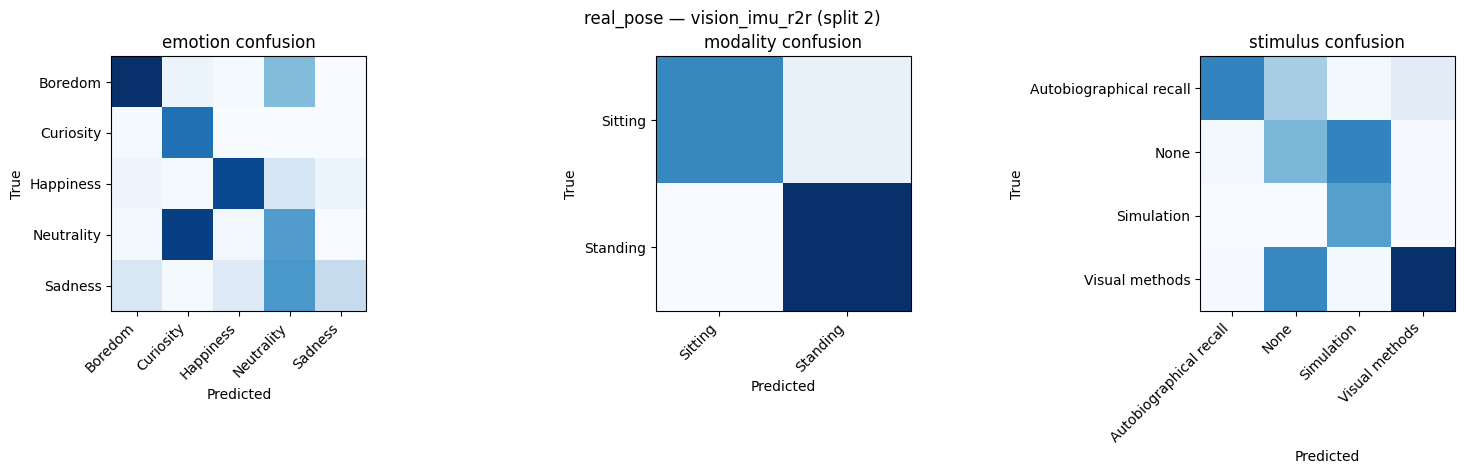

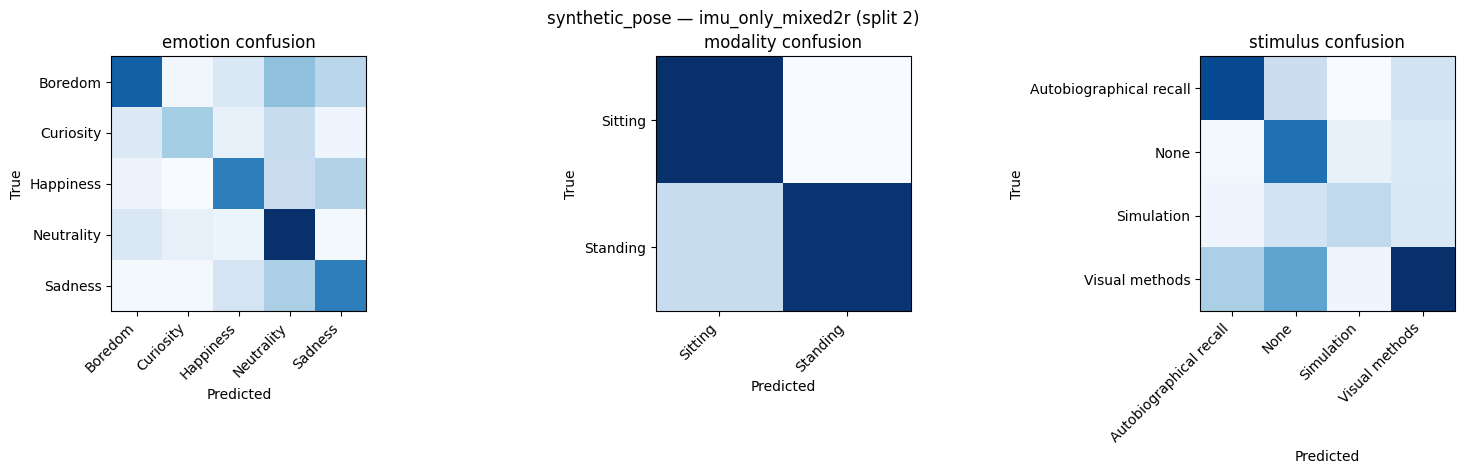

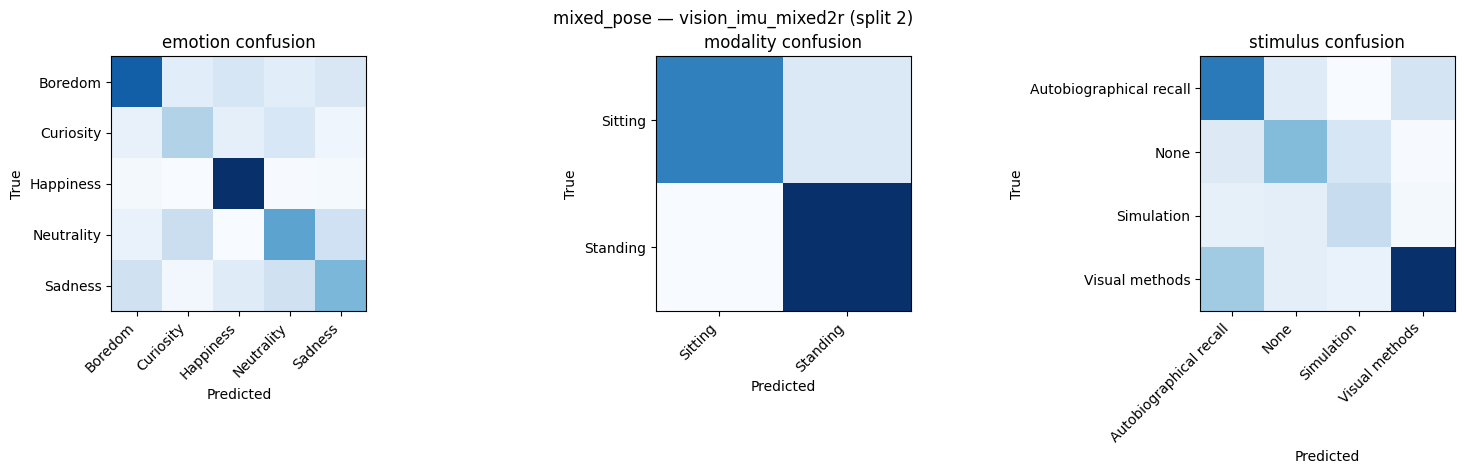

In [11]:
if TORCH_READY:
    from evaluation.classifiers.metrics import plot_confusion_matrices

    for result in (RESULT_REAL, RESULT_SYNTHETIC, RESULT_MIXED):
        suite = result['suite_result']
        if suite is None:
            continue
        best_experiment_name = suite['summary'].iloc[0]['experiment_name']
        best_result = max(
            (r for r in suite['results'] if r['experiment_name'] == best_experiment_name),
            key=lambda r: float(r['metrics'].get('global_score_macro_f1_mean') or float('-inf')),
        )
        split_suffix = '' if best_result.get('split_id') is None else f" (split {best_result['split_id']})"
        fig, axes = plot_confusion_matrices(best_result['metrics'], result['dataset_bundle']['label_encoders'])
        fig.suptitle(f"{result['label']} — {best_experiment_name}{split_suffix}", y=1.02)
        plt.show()